In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load the dataset

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# explore the data
df.shape # how many rows and columns
df.info() # data types
df.describe() #statistics summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# how many people survived?
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [ ]:
# now lets visualize the data

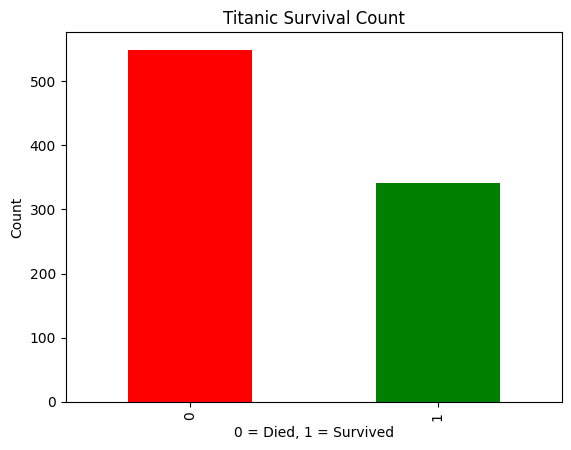

In [7]:
# bar chart of surviovors
df['Survived'].value_counts().plot(kind='bar',color=['red','green'])
plt.title('Titanic Survival Count')
plt.xlabel('0 = Died, 1 = Survived')
plt.ylabel('Count')
plt.show()

In [8]:
# did gender affect survival?
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

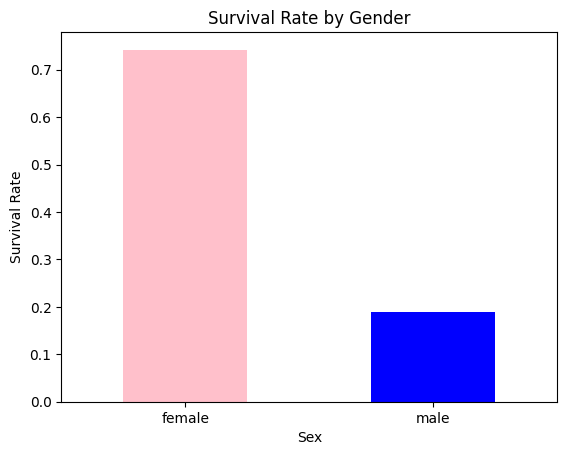

In [9]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['pink', 'blue'])
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# did passenger class rich vs poor matter ?

In [10]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [ ]:
# data cleaning

In [11]:
#check missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop(columns=['Cabin'], inplace=True)

In [14]:
# verify no more missing values
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [ ]:
# feature engineering

In [17]:
# create family size column
df['FamilySize'] = df['SibSp'] +df ['Parch'] + 1
df['FamilySize'].value_counts()

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [18]:
df.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [23]:
#did age affect survival ? 

df.groupby(pd.cut(df['Age'], bins=[0,18,35,60,100],
labels=['Child','Young Adult','Adult','Senior']))['Survived'].mean()

C:\Users\Admin03\AppData\Local\Temp\ipykernel_8952\2971366898.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['Age'], bins=[0,18,35,60,100],


Age
Child          0.503597
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64

C:\Users\Admin03\AppData\Local\Temp\ipykernel_8952\1366089313.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Survived'].mean().plot(kind='bar',


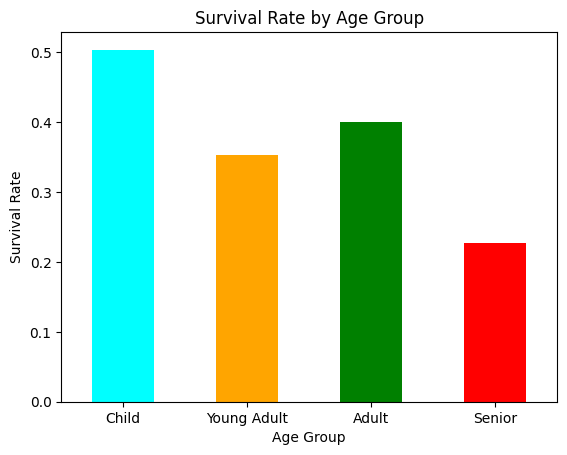

In [27]:
# correct way - shows survival RATE per age group
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,18,35,60,100], 
labels=['Child','Young Adult','Adult','Senior'])

df.groupby('AgeGroup')['Survived'].mean().plot(kind='bar', 
color=['cyan','orange','green','red'])
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

"I want to group ages" → Google "pandas group ages into bins"
"I want average per group" → .mean()
"My labels are tilted" → Google "matplotlib rotate xticks"

Question first → Code second

QuestionCodeHow many missing values? = df.isnull().sum()

What's the average ? = mean()

Group by category ? = groupby()

Split numbers into groups ? = pd.cut()

Count occurrences ? = value_counts()

Show a chart? = plot()

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [31]:
# select feature for our model
X = df[['Pclass','Age','SibSp','Parch','Fare','FamilySize']]
Y = df['Survived']
# split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(712, 6)
(179, 6)


X = the columns we feed into the machine
y = the column we want the machine to predict

So in plain English:

X = inputs (age, class, fare, family size...)
y = output (did they survive? 0 or 1)

In [32]:
# create and train the model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
# test the model
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.6368715083798883

In [34]:
# improved model with max_depth
model2 = DecisionTreeClassifier(max_depth=4, random_state=42)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
accuracy_score(y_test, y_pred2)

0.7150837988826816

In [35]:
# convert Sex to numbers first
df['Sex_encoded'] = (df['Sex'] == 'female').astype(int)

# new model with Sex included
X2 = df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Sex_encoded']]
y = df['Survived']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y, test_size=0.2, random_state=42)

model3 = DecisionTreeClassifier(max_depth=4, random_state=42)
model3.fit(X_train2, y_train2)
y_pred3 = model3.predict(X_test2)
accuracy_score(y_test2, y_pred3)

0.7988826815642458

In [36]:
# what features matter most?
import pandas as pd
feature_importance = pd.DataFrame({
    'Feature': X2.columns,
    'Importance': model3.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

       Feature  Importance
6  Sex_encoded    0.580531
0       Pclass    0.200817
4         Fare    0.087605
1          Age    0.076532
5   FamilySize    0.052050
3        Parch    0.002466
2        SibSp    0.000000
